In [1]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Helper function to display images in the notebook without color issues (OpenCV uses BGR, Matplotlib uses RGB)
def display_image(img_array, size=(10, 10)):
    img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=size)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

print("✅ Setup complete. Ready for inference.")

✅ Setup complete. Ready for inference.


In [2]:
MODEL_PATH = "../models/best.pt"

# Load the model
model = YOLO(MODEL_PATH)

# Let's define your class names so the output makes sense to us
CLASS_NAMES = {
    0: "bin_caged",
    1: "bin_elevated",
    2: "bin_ground",
    3: "trap_object"
}

print(f"✅ Model loaded successfully from {MODEL_PATH}")

✅ Model loaded successfully from ../models/best.pt



image 1/1 /media/ronit/SharedVolume/SignalSprint/ml_backend/notebooks/../test_data/images/img_005.png: 640x640 (no detections), 5.0ms
Speed: 1.6ms preprocess, 5.0ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
🔍 YOLO Raw Inference Output:


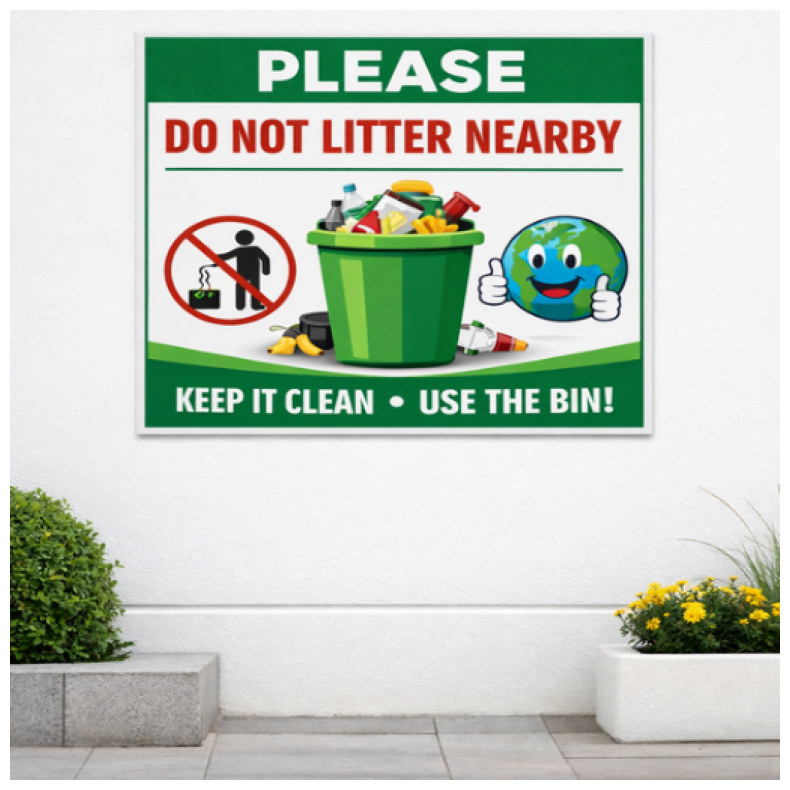

In [ ]:
# Point this to an image in your test set
TEST_IMAGE_PATH = "../test_data/images/img_006.png"

# Run inference! (conf=0.5 means we only want predictions it is at least 50% sure about)
results = model.predict(source=TEST_IMAGE_PATH, conf=0.7)

# Extract the first result (since we only passed one image)
result = results[0]

# YOLO has a built-in .plot() function that draws the boxes for you
annotated_img = result.plot()

print("🔍 YOLO Raw Inference Output:")
display_image(annotated_img)

In [ ]:
# We will store our valid targets here for Stage 2 (the ViT processing)
valid_targets = []

# result.boxes contains all the bounding boxes found in the image
for box in result.boxes:
    # 1. Extract data
    class_id = int(box.cls[0].item())
    confidence = float(box.conf[0].item())
    class_name = CLASS_NAMES[class_id]
    
    # Get bounding box coordinates [x_min, y_min, x_max, y_max]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    
    # 2. THE SINK LOGIC: If it's a trap, we completely ignore it!
    if class_name == "trap_object":
        print(f"🛡️ Ignored a {class_name} (Conf: {confidence:.2f})")
        continue
        
    # 3. Process actual targets (Classes 0, 1, 2)
    print(f"🎯 Valid Target Found: {class_name} (Conf: {confidence:.2f}) at [{x1}, {y1}, {x2}, {y2}]")
    
    # We save the cropped image of the bin for Stage 2
    # cv2 loads images as numpy arrays, so we can just slice them!
    original_img = cv2.imread(TEST_IMAGE_PATH)
    cropped_bin = original_img[y1:y2, x1:x2]
    
    valid_targets.append({
        "type": class_name,
        "crop": cropped_bin,
        "coords": (x1, y1, x2, y2)
    })

print(f"\n✅ Stage 1 Complete. Passed {len(valid_targets)} valid bins to the pipeline.")